# Programación óptima multiobjetivo de una microrred conectada a la red mediante MILP
**EMS, MILP, UC+ED, scheduling**

V1: Versión en PYOMO basado en [https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html](https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html) y en el Ejemplo 12.15 del libro [Model Building in Mathematical Programming](https://share.google/ovWcmGq54LiyOcWm8) de H. Paul Williams (5ª edición, págs. 270-271 y 325-326).

Formulación MILP con:
- Satisfacción exacta de la demanda por período
- Restricción de reserva operativa (15% sobre la demanda neta)
- Costos fijos por generador activo, costos marginales y costos de arranque
- Objetivo: minimizar costo total de operación

V2: El problema de Williams de despacho nacional (≈ 45 GW) redimensionado a escala de microrred (≈ 2.1 MW pico). Se reemplazaron los generadores térmicos por generadores diesel. Se agregaron restricciones de Min Up-Time y Min Down-Time, costos de apagado y linealización por tramos de la curva cuadrática de combustible.

V3: Se pasa de una representación agregada de la demanda en 5 bloques horarios a una discretización horaria completa (24 períodos).

V4: Se agregan restricciones de rampa (ramp-up y ramp-down) para limitar la tasa de cambio de producción entre períodos consecutivos. Las restricciones se formulan de manera trivialmente satisfecha (ramp_limit = Pmax) dado que los generadores diesel tienen una dinámica de carga mucho más rápida que el paso de tiempo de 1 hora.

V5: Se incorpora un generador fotovoltaico (GFV). Los datos de irradiancia y temperatura corresponden al parque solar de la UTN FR Santa Fe, día 01/01/2019 (promedios horarios).

V6: Conexión a la red de servicio (grid-tied operation). La microrred puede importar energía del mercado (`p_buy[t]`) o exportar excedentes (`p_sell[t]`). Se agrega una variable binaria `is_buying[t]` para garantizar que importación y exportación sean mutuamente excluyentes en cada período. Los precios horarios de compra/venta se basan en el perfil dinámico de Nemati et al. (BDEW, mercado alemán), escalado a $/kWh.

V7: **Análisis biobjetivo Costo–Emisiones CO₂.** Se incorpora el costo de externalidad del CO₂ producido por los generadores diesel y por la energía importada de la red. Se genera un **frente de Pareto** resolviendo 11 instancias MILP con λ ∈ {0.0, 0.1, …, 1.0}:

$$\min \quad \lambda \cdot C^{\mathrm{op}} + (1-\lambda) \cdot C^{\mathrm{em}}$$

Los datos de factores de emisión y costos de externalidad provienen de la Tabla 2.2 de Nemati et al. (2017). Se agregó un factor `R_SCALE = 16.6` para que la magnitud de $C^{\mathrm{em}}$ sea comparable con $C^{\mathrm{op}}$.

## Problema: Gestión Energética de Microrred con generadores despachables, generación renovable y red

Una flota de 25 grupos generadores diesel está disponible para satisfacer la demanda eléctrica de una microrred a lo largo de un día:

| demand_hourly | |
| :------------------------------- | :-------------------------------- |
| 820, 790, 810, 800, 830, 870, | 00–05: valle nocturno |
| 1050,1380,1575,1420,1350,1380, | 06–11: rampa matutina y mañana |
| 1520,1480,1400,1620,1850,2050, | 12–17: tarde y rampa vespertina |
| 2100,1980,1750,1550,1350,1100, | 18–23: pico y descenso nocturno |

Hay tres tipos de generadores diesel disponibles, 18 pequeños (40 KW), 12 medianos (100 KW) y 3 grandes (250 KW). Cada generador opera entre un nivel mínimo (50% de capacidad nominal) y un nivel máximo. Existen costos de O&M (operación y mantenimiento) fijos, costos de combustible (modelados con curva cuadrática linealizada), costos de arranque y de apagado. Cada generador debe permanecer encendido/apagado un tiempo mínimo tras cada transición de estado. 

Además de satisfacer las demandas de carga estimadas, debe haber suficientes generadores funcionando en cualquier momento para que sea posible satisfacer un aumento de carga de hasta el 15%. Este aumento tendría que lograrse ajustando la salida de los generadores que ya están operando dentro de sus límites permitidos.

La capacidad total instalada es 2470 kW (18×40 + 12×100 + 3×250). Considerando la reserva del 15%, la demanda máxima factible es ≈ 2148 kW, por lo que el pico de 2100 kW tiene margen de seguridad.

Además, se dispone de un generador fotovoltaico de 400 kWp (1000 módulos × 400 Wp). Los datos de demanda durante las 24 horas y las características de los generadores se muestran en la sección Carga de datos.

La microrred opera en modo conectado (*grid-tied*). El sistema puede intercambiar energía con la red de servicio a través del Punto de Acoplamiento Común (PCC):

- Importación (`p_buy[t]`): comprar energía de la red cuando el precio de mercado es menor que el costo marginal de generación diesel.
- Exportación (`p_sell[t]`): vender excedentes de generación FV (si los hubiera) o diesel a la red cuando el precio de venta lo justifica.

El balance de energía en cada período es ahora:


\begin{align}
\sum_{g \in G} P^{\mathrm{Diesel}}_{g,t} + P^{\mathrm{PV}}_t + p^{\mathrm{buy}}_t - p^{\mathrm{sell}}_t = D_t \qquad \forall t \in T
\end{align}

Donde

* $P^{\mathrm{Diesel}}_{g,t}$: potencia del generador $g \in G$ en el período $t$ [kW] 
* $P^{\mathrm{PV}}_t$: potencia fotovoltaica en el período $t$ [kW]
* $p^{\mathrm{buy}}_t$: Potencia importada desde la red de servicio en el período $t$ [kW]
* $p^{\mathrm{sell}}_t$: Potencia exportada a la red de servicio en el período $t$ [kW]
* $D_t$: demanda esperada en el período $t$ [kW]$

La capacidad del transformador del PCC limita el intercambio en ambas direcciones a $\bar{P}^{\mathrm{PCC}} = 500\,\mathrm{kW}$.

La reserva operativa se mantiene sobre capacidad diesel instalada y activa, sin contar la importación de red. Esto refleja el requerimiento de que la microrred pueda operar en isla ante una desconexión de la red.

**Novedad V7**: Se agrega el análisis de emisiones CO₂ como segundo objetivo, generando un frente de Pareto Costo–Emisiones.

In [1]:
import pyomo.environ as pe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import time
import os
os.makedirs('images', exist_ok=True)

## Creación de Archivos de Datos

Las siguientes celdas generan los archivos CSV con los parámetros de la microrred. Si ya existen, los sobreescribe.

Los datos son idénticos a V6, con nombres de archivo actualizados para la versión 7.

In [2]:
os.makedirs("data", exist_ok=True)

# ── Generadores diesel ────────────────────────────────────────────────────────
gen_lines = [
 "generator_class,num_available,min_output,max_output,cost_per_hour,startup_cost,shutdown_cost,min_up_time,min_down_time,ramp_limit,state0",
 "diesel_small,18,20.0,40.0,2.5,5.0,2.5,1,1,40.0,12",
 "diesel_med,12,50.0,100.0,5.8,12.0,6.0,1,1,100.0,10",
 "diesel_large,3,125.0,250.0,14.5,25.0,12.5,1,1,250.0,2",
]
with open("data/generators_diesel_v7.csv", "w") as f:
 f.write("\n".join(gen_lines) + "\n")

# ── Datos solares (UTN FR Santa Fe, 01/01/2019) ───────────────────────────────
solar_lines = ["hora,irradiancia,temperatura",
 "0,0.0,27.9","1,0.0,27.55","2,0.0,27.17","3,0.0,26.81",
 "4,0.0,26.48","5,0.0,26.13","6,16.0,26.36","7,89.16,27.53",
 "8,335.67,29.08","9,540.83,32.1","10,679.33,32.4","11,990.67,33.98",
 "12,773.17,35.03","13,739.0,34.73","14,196.5,30.81","15,747.17,32.45",
 "16,668.67,33.65","17,402.33,32.86","18,88.67,31.15","19,51.17,29.46",
 "20,5.17,26.98","21,0.0,28.15","22,0.0,28.67","23,0.0,28.5"]
with open("data/GFV_UTN_santafe_v7.csv", "w") as f:
 f.write("\n".join(solar_lines) + "\n")

# ── Precios de mercado (Nemati et al., BDEW escalado a $/kWh) ────────────────
price_profile = {
 **{h: (0.08, 0.04) for h in range(0, 7)},
 **{h: (0.22, 0.06) for h in range(7, 12)},
 **{h: (0.15, 0.05) for h in range(12, 18)},
 **{h: (0.48, 0.06) for h in range(18, 23)},
 23: (0.10, 0.04),
}
market_lines = ["hora,price_buy,price_sell"] + [f"{h},{b},{s}" for h,(b,s) in price_profile.items()]
with open("data/market_prices_v7.csv", "w") as f:
 f.write("\n".join(market_lines) + "\n")

# ── Demanda horaria ────────────────────────────────────────────────────────────
demand_hourly = [
 820, 790, 810, 800, 830, 870,
 1050,1380,1575,1420,1350,1380,
 1520,1480,1400,1620,1850,2050,
 2100,1980,1750,1550,1350,1100,
]
import datetime
base = datetime.datetime(2024, 1, 1)
tp_lines = ["time_period,expected_demand"] + [
 f"{base + datetime.timedelta(hours=h)},{d}" for h,d in enumerate(demand_hourly)]
with open("data/time_periods_v7.csv", "w") as f:
 f.write("\n".join(tp_lines) + "\n")

print("Archivos CSV creados:")
for fn in ["generators_diesel_v7.csv","GFV_UTN_santafe_v7.csv","market_prices_v7.csv","time_periods_v7.csv"]:
 print(f" data/{fn}")
print()
print("Perfil de precios (Nemati et al., BDEW):")
print(f" {'Hora':>5} {'price_buy':>12} {'price_sell':>12}")
print(" " + "-"*32)
for h in range(24):
 b, s = price_profile[h]
 print(f" {h:>5} {b:>12.2f} {s:>12.2f}")


Archivos CSV creados:
 data/generators_diesel_v7.csv
 data/GFV_UTN_santafe_v7.csv
 data/market_prices_v7.csv
 data/time_periods_v7.csv

Perfil de precios (Nemati et al., BDEW):
  Hora    price_buy   price_sell
 --------------------------------
     0         0.08         0.04
     1         0.08         0.04
     2         0.08         0.04
     3         0.08         0.04
     4         0.08         0.04
     5         0.08         0.04
     6         0.08         0.04
     7         0.22         0.06
     8         0.22         0.06
     9         0.22         0.06
    10         0.22         0.06
    11         0.22         0.06
    12         0.15         0.05
    13         0.15         0.05
    14         0.15         0.05
    15         0.15         0.05
    16         0.15         0.05
    17         0.15         0.05
    18         0.48         0.06
    19         0.48         0.06
    20         0.48         0.06
    21         0.48         0.06
    22         0.48         0.

## Modelo de Generador Fotovoltaico
**Basado en Loyarte (2019)**

La potencia eléctrica entregada por un GFV con $N$ módulos idénticos operando en MPP (Maximum Power Point) es:

$$P_{\mathrm{PV}}[kW] = N \cdot \frac{G}{G_{\mathrm{std}}} \cdot P_{\mathrm{pico}} \cdot \bigl[1 + k_p \cdot (T_c - T_r)\bigr] \cdot \eta \cdot 10^{-3} \tag{1}$$

Donde:

- $N$: cantidad de módulos instalados
- $G$: irradiancia global incidente en forma normal a los módulos [W/m²]
- $G_{\mathrm{std}}$: irradiancia estándar (STC) [W/m²]
- $T_r$: temperatura de referencia (STC) [°C]
- $T_c$: temperatura de celda [°C]
- $P_{\mathrm{pico}}$: potencia pico del módulo [W]
- $k_p$: coeficiente de temperatura de potencia [°C⁻¹]
- $\eta$: rendimiento global del sistema (inversor + pérdidas BOS) [p.u.]

La temperatura de la celda difiere de la temperatura ambiente $T$. En la literatura se disponen decenas de modelos matemáticos que permiten estimar $T_c$ a partir de mediciones de $T$. El modelo más sencillo, válido únicamente en ausencia de viento, indica que la relación se puede aproximar según:

$$T_c = T + 0{,}031\,[°C \cdot m^2/W] \cdot G \tag{2}$$

> **Nota:** Como se indica en Loyarte, las mediciones de irradiancia de la estación meteorológica se toman sobre superficie horizontal. En este ejercicio se asume, por simplicidad, que los valores corresponden directamente a $G$ (irradiancia normal a los módulos).

Los circuitos inversores funcionan adecuadamente siempre que la producción supere un umbral mínimo $\mu$ porcentual respecto a $P_{inv}$ (potencia del inversor); si no lo supera, la instalación no entrega potencia. Asimismo, $P_{inv}$ opera como límite superior del GFV:

$$P_{\text{mín}}\,[kW] = \frac{\mu(\%)}{100} \cdot P_{inv} \tag{3}$$

$$
P_r\,[kW] =
\begin{cases}
0 & \text{si } P \le P_{\text{mín}} \\
P & \text{si } P_{\text{mín}} < P \le P_{inv} \\
P_{inv} & \text{si } P > P_{inv}
\end{cases}
\tag{4}
$$

In [3]:
# ── Parámetros del GFV (Loyarte) ─────────────────────────────────────────────
PV_N      = 1000    # 12 módulos
PV_Ppico  = 400     # 240 W por módulo
PV_kp     = -0.0044 # °C⁻¹ coeficiente temperatura-potencia
PV_Tr     = 25.0    # °C temperatura de referencia
PV_Gstd   = 1000.0  # W/m² irradiancia estándar
PV_eta    = 0.97    # rendimiento global (inversor + BOS)
PV_Pinv   = 400     # 2.5 kW, potencia nominal del inversor
PV_mu     = 2.0     # %, umbral mínimo de arranque del inversor

def loyarte_pv(G, T_amb, N=PV_N, Ppico=PV_Ppico, kp=PV_kp,
               Tr=PV_Tr, Gstd=PV_Gstd, eta=PV_eta, Pinv=PV_Pinv, mu=PV_mu):
    """Modelo Loyarte (ec. 1-2) con límites de inversor (ec. 3-4). Retorna P_PV en kW."""
    if G <= 0:
        return 0.0
    Tc = T_amb + 0.031 * G                                        # ec. (2): temperatura de celda
    P  = N * (G / Gstd) * Ppico * (1 + kp*(Tc-Tr)) * eta * 1e-3   # ec. (1): potencia [kW]
    Pmin = (mu / 100) * Pinv                                       # ec. (3)
    P = 0 * (P < Pmin) + P * (Pmin <= P <= Pinv) + Pinv * (P > Pinv)  # ec. (4)
    return P

# ── Carga de datos solares y cálculo del perfil PV ───────────────────────────
solar_data = pd.read_csv("data/GFV_UTN_santafe.csv", index_col="hora")

pv_profile = {}
for h in range(24):
    G   = solar_data.loc[h, 'irradiancia']
    T   = solar_data.loc[h, 'temperatura']
    pv_profile[h] = round(loyarte_pv(G, T), 2)

print(f"GFV: {PV_N} módulos × {PV_Ppico} Wp = {PV_N*PV_Ppico/1000:.3f} kWp nominales")
print(f"     kp={PV_kp} °C⁻¹ | η={PV_eta} | Tr={PV_Tr}°C | Gstd={PV_Gstd} W/m²")
print(f"     P_inv={PV_Pinv} kW | μ={PV_mu}% → P_mín={(PV_mu/100)*PV_Pinv:.4f} kW")
print()
print(f"{'Hora':>5} {'G (W/m²)':>10} {'T_amb (°C)':>11} {'T_c (°C)':>10} {'P_PV (kW)':>11}")
print("-" * 50)
for h in range(24):
    G  = solar_data.loc[h, 'irradiancia']
    T  = solar_data.loc[h, 'temperatura']
    Tc = T + 0.031*G if G > 0 else T
    print(f"{h:>5} {G:>10.2f} {T:>11.2f} {Tc:>10.2f} {pv_profile[h]:>11.1f}")
print("-" * 50)
print(f"{'Pico':>5} {'':>10} {'':>11} {'':>10} {max(pv_profile.values()):>11.1f}  kW")
print(f"{'Total':>5} {'':>10} {'':>11} {'':>10} {sum(pv_profile.values()):>11.1f}  kWh/día")

GFV: 1000 módulos × 400 Wp = 400.000 kWp nominales
     kp=-0.0044 °C⁻¹ | η=0.97 | Tr=25.0°C | Gstd=1000.0 W/m²
     P_inv=400 kW | μ=2.0% → P_mín=8.0000 kW

 Hora   G (W/m²)  T_amb (°C)   T_c (°C)   P_PV (kW)
--------------------------------------------------
    0       0.00       27.90      27.90         0.0
    1       0.00       27.55      27.55         0.0
    2       0.00       27.17      27.17         0.0
    3       0.00       26.81      26.81         0.0
    4       0.00       26.48      26.48         0.0
    5       0.00       26.13      26.13         0.0
    6      16.00       26.36      26.86         0.0
    7      89.16       27.53      30.29        33.8
    8     335.67       29.08      39.49       121.9
    9     540.83       32.10      48.87       187.8
   10     679.33       32.40      53.46       230.6
   11     990.67       33.98      64.69       317.2
   12     773.17       35.03      59.00       255.1
   13     739.00       34.73      57.64       245.6
   14     1

## Carga de Datos

Se cargan los DataFrames con los parámetros de generadores, demanda, datos solares y precios de mercado.

In [4]:
generator_data = pd.read_csv('data/generators_diesel_v7.csv', index_col='generator_class')
generator_data

,num_available,min_output,max_output,cost_per_hour,startup_cost,shutdown_cost,min_up_time,min_down_time,ramp_limit,state0
generator_class,,,,,,,,,,
diesel_small,18,20.0,40.0,2.5,5.0,2.5,1,1,40.0,12
diesel_med,12,50.0,100.0,5.8,12.0,6.0,1,1,100.0,10
diesel_large,3,125.0,250.0,14.5,25.0,12.5,1,1,250.0,2


In [5]:
time_period_data = pd.read_csv('data/time_periods_v7.csv', parse_dates=['time_period'],
                               index_col='time_period')
time_period_data

,expected_demand
time_period,
2024-01-01 00:00:00,820
2024-01-01 01:00:00,790
2024-01-01 02:00:00,810
2024-01-01 03:00:00,800
2024-01-01 04:00:00,830
2024-01-01 05:00:00,870
2024-01-01 06:00:00,1050
2024-01-01 07:00:00,1380
2024-01-01 08:00:00,1575


In [6]:
solar_data_df = pd.read_csv("data/GFV_UTN_santafe_v7.csv", index_col="hora")
solar_data_df

,irradiancia,temperatura
hora,,
0,0.00,27.90
1,0.00,27.55
2,0.00,27.17
3,0.00,26.81
4,0.00,26.48
5,0.00,26.13
6,16.00,26.36
7,89.16,27.53
8,335.67,29.08


In [7]:
market_data = pd.read_csv('data/market_prices_v7.csv', index_col='hora')
market_data

,price_buy,price_sell
hora,,
0,0.08,0.04
1,0.08,0.04
2,0.08,0.04
3,0.08,0.04
4,0.08,0.04
5,0.08,0.04
6,0.08,0.04
7,0.22,0.06
8,0.22,0.06


## Conjuntos

Se definen los conjuntos de generadores y períodos de tiempo para el modelo MILP.

In [8]:
GENERATORS = list(generator_data.index)
TIME_PERIODS = list(time_period_data.index)
T = list(range(len(TIME_PERIODS)))
print(f'Clases de generadores : {GENERATORS}')
print(f'Numero de periodos    : {len(T)}')

Clases de generadores : ['diesel_small', 'diesel_med', 'diesel_large']
Numero de periodos    : 24


## Parámetros

Los parámetros del modelo se construyen como diccionarios Python a partir de los DataFrames cargados.

- $n_g$: unidades disponibles de la clase $g$
- $P^{\min}_g$, $P^{\max}_g$: límites de producción por unidad [kW]
- $c_g$: costo fijo de O&M por hora por unidad activa [$/h]
- $s^u_g$: costo de arranque [$]
- $s^d_g$: costo de apagado [$]
- $\tau^{\mathrm{up}}_g$, $\tau^{\mathrm{dn}}_g$: tiempos mínimos de encendido/apagado [períodos]
- $a^0_g$: estado inicial (unidades activas antes del primer período)
- $P^{\mathrm{PV}}_t$: potencia fotovoltaica en el período $t$ [kW] — calculada con modelo Loyarte
- $D_t$: demanda bruta esperada en el período $t$ [kW]
- $\pi^{\mathrm{buy}}_t$: precio de importación desde la red [$/kWh]
- $\pi^{\mathrm{sell}}_t$: precio de exportación hacia la red [$/kWh]
- $\bar{P}^{\mathrm{PCC}}$: capacidad máxima de intercambio en el PCC [kW]
- $M$: constante Big-M para la restricción de no-simultaneidad [kW]

**Novedad V7**: Se agregan los parámetros de emisiones CO₂ (ver sección posterior).

In [9]:
# ── Parámetros por clase de generador ───────────────────────────────────────
num_available = generator_data['num_available'].to_dict()
min_output    = generator_data['min_output'].to_dict()
max_output    = generator_data['max_output'].to_dict()
cost_per_hour = generator_data['cost_per_hour'].to_dict()
startup_cost  = generator_data['startup_cost'].to_dict()
shutdown_cost = generator_data['shutdown_cost'].to_dict()
min_up_time   = generator_data['min_up_time'].to_dict()
min_down_time = generator_data['min_down_time'].to_dict()
ramp_limit    = generator_data['ramp_limit'].to_dict()
state0        = generator_data['state0'].to_dict()

# ── Parámetros por período (indexados por entero) ────────────────────────────
expected_demand = {i: time_period_data['expected_demand'].iloc[i] for i in T}

pv_output   = {i: pv_profile[i] for i in T}
price_buy   = {i: market_data.loc[i, 'price_buy'] for i in T}
price_sell  = {i: market_data.loc[i, 'price_sell'] for i in T}

PCC_LIMIT = 500.0  # kW
BIG_M = PCC_LIMIT

# Demanda neta = demanda bruta − generación PV
net_demand = {i: expected_demand[i] - pv_output[i] for i in T}

# Reserva: 15% sobre demanda bruta, solo capacidad diesel (reserva de isla)
minimum_active_capacity = {i: round(expected_demand[i]*1.15, 2) for i in T}

print('Parámetros cargados correctamente.')
print(f'  Capacidad total diesel: {sum(num_available[g]*max_output[g] for g in GENERATORS):.0f} kW')
print(f'  Capacidad FV: {max(pv_profile.values()):.1f} kW pico')
print(f'  Demanda pico: {max(expected_demand.values()):.0f} kW')
print(f'  Reserva requerida (15%): {max(minimum_active_capacity.values()):.0f} kW')

Parámetros cargados correctamente.
  Capacidad total diesel: 2670 kW
  Capacidad FV: 317.2 kW pico
  Demanda pico: 2100 kW
  Reserva requerida (15%): 2415 kW


## Linealización de la Curva de Costo de Combustible
### Enfoque Parisio (2014)

Dado que los MILP son computacionalmente más eficientes que los MIQP, la función de costo de combustible de un generador diesel:

\begin{align}
f(P) = a P^2 + b P \quad [\text{\$/h}]
\end{align}

se aproxima por el máximo de funciones afines sin introducir variables binarias adicionales:

$$f(P) \approx \sigma = \max_{j=1,\dots,n}\{S_j P + s_j\}$$

donde los coeficientes de cada segmento $j$ se obtienen evaluando la tangente de $f$ en el punto de soporte $P_j$:

$$S_j = f'(P_j) = 2aP_j + b \qquad s_j = f(P_j) - S_j P_j = -aP_j^2$$

Extensión a clases de generadores (formulación agregada): si hay $n_{g,t}$ unidades activas de la clase $g$ produciendo $P^{\mathrm{Diesel}}_{g,t}$ kW en total, el costo de combustible agregado es:

$$n_{g,t} \cdot f\!\left(\frac{P^{\mathrm{Diesel}}_{g,t}}{n_{g,t}}\right) = a\frac{{P^{\mathrm{Diesel}}_{g,t}}^2}{n_{g,t}} + b\, P^{\mathrm{Diesel}}_{g,t}$$

Con la aproximación lineal tangente en cada punto de soporte, esto se convierte en el conjunto de restricciones lineales:

$$\sigma_{g,t} \geq S_j^{g} \cdot P^{\mathrm{Diesel}}_{g,t} + s_j^{g} \cdot n_{g,t} \qquad \forall j = 1, \dots, n_{\mathrm{seg}}$$

Esta formulación es lineal porque $S_j^{g}$ y $s_j^{g}$ son constantes, $P^{\mathrm{Diesel}}_{g,t}$ es continua y $n_{g,t}$ es entera.

Se definen los coeficientes cuadráticos de la función de costo de combustible por unidad:

$$f_g(P) = a_g P^2 + b_g P \quad [\text{\$/h}]$$

y se calculan los segmentos lineales evaluando las tangentes en $n_{\mathrm{seg}} = 3$ puntos de soporte equidistantes entre $P^{\min}_g$ y $P^{\max}_g$.

Los coeficientes (Tabla 2.1 de Nemati) $a$ en $ml/kW^{2}h$ y $b$ en $l/kWh$ se multiplicaron por un precio de combustible estimado de $1.2 $/l$.


In [10]:
quad_params = {
    'diesel_small': {'a': 0.003, 'b': 0.18},
    'diesel_med':   {'a': 0.0012, 'b': 0.20},
    'diesel_large': {'a': 0.0004, 'b': 0.22},
}
N_SEG = 3
lin_segments = {}
for g in GENERATORS:
    a, b = quad_params[g]['a'], quad_params[g]['b']
    support = np.linspace(min_output[g], max_output[g], N_SEG)
    lin_segments[g] = {
        'slopes':     [2*a*pj + b for pj in support],
        'intercepts': [-a*pj**2   for pj in support],
        'support':    support
    }
SEGMENTS = list(range(N_SEG))

print('Segmentos de linealizacion calculados para:', GENERATORS)
for g in GENERATORS:
    print(f"\n--- {g} ---")
    for j in SEGMENTS:
        print(f"  Segmento {j}: pendiente = {lin_segments[g]['slopes'][j]:.4f}, "
              f"intercepto = {lin_segments[g]['intercepts'][j]:.4f}, "
              f"punto soporte = {lin_segments[g]['support'][j]:.1f} kW")

Segmentos de linealizacion calculados para: ['diesel_small', 'diesel_med', 'diesel_large']

--- diesel_small ---
  Segmento 0: pendiente = 0.3000, intercepto = -1.2000, punto soporte = 20.0 kW
  Segmento 1: pendiente = 0.3600, intercepto = -2.7000, punto soporte = 30.0 kW
  Segmento 2: pendiente = 0.4200, intercepto = -4.8000, punto soporte = 40.0 kW

--- diesel_med ---
  Segmento 0: pendiente = 0.3200, intercepto = -3.0000, punto soporte = 50.0 kW
  Segmento 1: pendiente = 0.3800, intercepto = -6.7500, punto soporte = 75.0 kW
  Segmento 2: pendiente = 0.4400, intercepto = -12.0000, punto soporte = 100.0 kW

--- diesel_large ---
  Segmento 0: pendiente = 0.3200, intercepto = -6.2500, punto soporte = 125.0 kW
  Segmento 1: pendiente = 0.3700, intercepto = -14.0625, punto soporte = 187.5 kW
  Segmento 2: pendiente = 0.4200, intercepto = -25.0000, punto soporte = 250.0 kW


## Parámetros de Emisiones CO₂
### Fuente: Nemati et al. (2017), Tabla 2.2

En la versión 7 se incorpora el análisis de emisiones de CO₂ como segundo objetivo del modelo. Los factores de emisión corresponden al CO₂ equivalente por kWh generado.

El costo de externalidad $\alpha$ convierte kg de CO₂ a \$, haciendo que $C^{\mathrm{em}}$ sea directamente comparable con $C^{\mathrm{op}}$ en la función objetivo ponderada.

$$C^{\mathrm{em}} = \alpha_{\mathrm{CO_2}} \cdot \left[ \beta_{\mathrm{DG}} \sum_{g,t} x_{g,t} + \beta_{\mathrm{grid}} \sum_t p^{\mathrm{buy}}_t \right] \quad [\$]$$

### Parámetros de emisiones (Nemati et al., Tabla 2.2)

| Fuente | Factor de emisión β | Costo externalidad α | Unidad |
|:---|---:|---:|:---|
| Generadores diesel (DG) | 649,5 | 0,0275 | g CO₂/kWh — \$/kg |
| Red eléctrica (main grid) | 889,1 | 0,0275 | g CO₂/kWh — \$/kg |
| Solar FV | 0 | — | — |

> **Observación clave:** $\beta_{\mathrm{grid}}$ (889 g/kWh) > $\beta_{\mathrm{diesel}}$ (649 g/kWh). Esto refleja el mix eléctrico alemán de 2017, con alta participación de carbón. Como consecuencia, **minimizar emisiones implica reducir la importación de red y aumentar la generación diesel propia** — un trade-off no intuitivo pero físicamente correcto para ese contexto. En el frente de Pareto se verá que moverse desde $\lambda=1$ (solo costo) hacia $\lambda=0$ (solo emisiones) aumenta el costo operativo a la vez que reduce las emisiones.

In [11]:
# ── Parámetros de emisiones CO2 (Nemati et al. 2017, Tabla 2.2) ──────────────
ALPHA_CO2   = 0.0275   # $/kg — costo de externalidad del CO2

# Diccionario de emisiones por clase de generador
BETA_DIESEL = {
    'diesel_large': 0.600,  # Más limpios
    'diesel_med': 0.650,    # Promedio
    'diesel_small': 0.720   # Más sucios
}

# Perfil horario de emisiones de la red (simulando penetración solar)
# Noche (sucia), Mañana (media), Mediodía (limpia), Tarde/Noche (sucia)
BETA_GRID = {
    **{h: 0.920 for h in range(0, 7)},   
    **{h: 0.750 for h in range(7, 10)},  
    **{h: 0.400 for h in range(10, 16)}, 
    **{h: 0.889 for h in range(16, 24)}
}

# FV: beta_pv = 0 (sin emisiones en operacion)

## Formulación Biobjetivo: Costo Operativo vs. Emisiones CO₂

### Función objetivo ponderada

Se combinan linealmente los dos objetivos mediante el parámetro de ponderación $\lambda \in [0, 1]$:

$$\min \; \lambda \cdot C^{\mathrm{op}} + (1-\lambda) \cdot C^{\mathrm{em}}$$

donde:

$$C^{\mathrm{op}} = \sum_{g,t}\bigl[c_g n_{g,t} + \sigma_{g,t} + s^u_g u_{g,t} + s^d_g v_{g,t}\bigr] + \sum_t \bigl[\pi^{\mathrm{buy}}_t p^{\mathrm{buy}}_t - \pi^{\mathrm{sell}}_t p^{\mathrm{sell}}_t\bigr]$$

$$C^{\mathrm{em}} = \alpha_{\mathrm{CO_2}} \cdot \Biggl[ \underbrace{\beta_{\mathrm{DG}} \sum_{g,t} x_{g,t}}_{\text{diesel}} + \underbrace{\beta_{\mathrm{grid}} \sum_t p^{\mathrm{buy}}_t}_{\text{red importada}} \Biggr]$$

Ambos objetivos están expresados en **\$**, lo que permite cuantificar la contribución de cada uno. Se agregó un factor `R_SCALE = 16.6` para que la magnitud de $C^{\mathrm{em}}$ sea comparable con $C^{\mathrm{op}}$. El FV no tiene emisiones. 

### Método de suma escalar ponderada

Se resuelven 11 instancias MILP independientes, una por cada valor de $\lambda \in \{0.0, 0.1, \dots, 1.0\}$. Cada instancia produce un punto del frente de Pareto. Con $\lambda=1$ se recupera exactamente el modelo de V6 (solo costo). Con $\lambda=0$ se minimizan solo las emisiones.

In [12]:
def build_and_solve(lam, solver_factory='appsi_highs', verbose=False):
#Otras opciones de solver: 'gurobi_direct', 'cbc', 'glpk'
    """
    Construye y resuelve el modelo UC V7 para un lambda dado.

    Parametros
    ----------
    lam : float in [0, 1]
        Peso del objetivo economico. lam=1 -> solo costo; lam=0 -> solo emisiones.

    Retorna
    -------
    dict con: lambda, c_op, c_em_cost, c_em_kg, c_em_diesel, c_em_grid,
    obj_weighted, e_diesel, e_buy, e_sell, cpu_time, status, pbuy_vals,
    psell_vals, diesel_vals, num_active_vals, output_vals
    """
    m = pe.ConcreteModel()

    # Conjuntos
    m.G = pe.Set(initialize=GENERATORS, ordered=True)
    m.T = pe.Set(initialize=T, ordered=True)
    m.J = pe.Set(initialize=SEGMENTS)

    # Parametros
    m.num_available = pe.Param(m.G, initialize=num_available)
    m.min_output    = pe.Param(m.G, initialize=min_output)
    m.max_output    = pe.Param(m.G, initialize=max_output)
    m.cost_per_hour = pe.Param(m.G, initialize=cost_per_hour)
    m.startup_cost  = pe.Param(m.G, initialize=startup_cost)
    m.shutdown_cost = pe.Param(m.G, initialize=shutdown_cost)
    m.min_up_time   = pe.Param(m.G, initialize=min_up_time)
    m.min_down_time = pe.Param(m.G, initialize=min_down_time)
    m.ramp_limit    = pe.Param(m.G, initialize=ramp_limit)
    m.state0        = pe.Param(m.G, initialize=state0)
    m.expected_demand = pe.Param(m.T, initialize=expected_demand)
    m.pv_output     = pe.Param(m.T, initialize=pv_output)
    m.minimum_active_capacity = pe.Param(m.T, initialize=minimum_active_capacity)
    m.price_buy     = pe.Param(m.T, initialize=price_buy)
    m.price_sell    = pe.Param(m.T, initialize=price_sell)
    m.pcc_limit     = pe.Param(initialize=PCC_LIMIT)
    m.big_m         = pe.Param(initialize=BIG_M)

    slope_data = {(g,j): lin_segments[g]['slopes'][j] for g in GENERATORS for j in SEGMENTS}
    intercept_data = {(g,j): lin_segments[g]['intercepts'][j] for g in GENERATORS for j in SEGMENTS}
    m.lin_slope     = pe.Param(m.G, m.J, initialize=slope_data)
    m.lin_intercept = pe.Param(m.G, m.J, initialize=intercept_data)

    # Variables
    m.output = pe.Var(m.G, m.T, within=pe.NonNegativeReals)
    m.sigma  = pe.Var(m.G, m.T, within=pe.NonNegativeReals)

    def na_bounds(m2,g,t): return (0, m2.num_available[g])
    m.num_active   = pe.Var(m.G, m.T, within=pe.NonNegativeIntegers, bounds=na_bounds)
    m.num_startup  = pe.Var(m.G, m.T, within=pe.NonNegativeIntegers)
    m.num_shutdown = pe.Var(m.G, m.T, within=pe.NonNegativeIntegers)

    def pcc_b(m2,t): return (0, m2.pcc_limit)
    m.p_buy   = pe.Var(m.T, within=pe.NonNegativeReals, bounds=pcc_b)
    m.p_sell  = pe.Var(m.T, within=pe.NonNegativeReals, bounds=pcc_b)
    m.is_buying = pe.Var(m.T, within=pe.Binary)

    # Restricciones---------------------------------------------------
    # Restricción de balance de energía
    def demand_rule(m2,t):
        return (sum(m2.output[g,t] for g in m2.G) + m2.pv_output[t]
                + m2.p_buy[t] - m2.p_sell[t] == m2.expected_demand[t])
    m.demand_constraint = pe.Constraint(m.T, rule=demand_rule)

    # Restricción de reserva operativa
    def reserve_rule(m2,t):
        return sum(m2.max_output[g]*m2.num_active[g,t] for g in m2.G) >= m2.minimum_active_capacity[t]
    m.reserve_constraint = pe.Constraint(m.T, rule=reserve_rule)

    # Límites de producción de potencia
    def out_lo(m2,g,t): return m2.output[g,t] >= m2.min_output[g]*m2.num_active[g,t]
    def out_hi(m2,g,t): return m2.output[g,t] <= m2.max_output[g]*m2.num_active[g,t]
    m.output_lower = pe.Constraint(m.G, m.T, rule=out_lo)
    m.output_upper = pe.Constraint(m.G, m.T, rule=out_hi)

    # Restricciones de encendido/apagado (start-up y shut-down)
    def su_rule(m2,g,t):
        if t==m2.T.first(): return pe.Constraint.Skip
        return m2.num_startup[g,t] >= m2.num_active[g,t] - m2.num_active[g,m2.T.prev(t)]
    m.startup_constraint = pe.Constraint(m.G, m.T, rule=su_rule)
    def su0_rule(m2,g):
        return m2.num_startup[g,m2.T.first()] >= m2.num_active[g,m2.T.first()] - m2.state0[g]
    m.initial_startup = pe.Constraint(m.G, rule=su0_rule)
    def sd_rule(m2,g,t):
        if t==m2.T.first(): return pe.Constraint.Skip
        return m2.num_shutdown[g,t] >= m2.num_active[g,m2.T.prev(t)] - m2.num_active[g,t]
    m.shutdown_constraint = pe.Constraint(m.G, m.T, rule=sd_rule)
    def sd0_rule(m2,g):
        return m2.num_shutdown[g,m2.T.first()] >= m2.state0[g] - m2.num_active[g,m2.T.first()]
    m.initial_shutdown = pe.Constraint(m.G, rule=sd0_rule)

    # Restricciones de tiempo mínimo encendido/apagado (min up-time y min down-time)
    def mut_rule(m2,g,t):
        mut = int(pe.value(m2.min_up_time[g]))
        if mut<=1: return pe.Constraint.Skip
        tl = list(m2.T)
        if t < mut-1: return pe.Constraint.Skip
        w = [tl[tau] for tau in range(t-mut+1, t) if tau>=0]
        return sum(m2.num_startup[g,tau] for tau in w) <= m2.num_active[g,tl[t]]
    m.min_up_time_constraint = pe.Constraint(m.G, m.T, rule=mut_rule)
    def mdt_rule(m2,g,t):
        mdt = int(pe.value(m2.min_down_time[g]))
        if mdt<=1: return pe.Constraint.Skip
        tl = list(m2.T)
        if t < mdt-1: return pe.Constraint.Skip
        w = [tl[tau] for tau in range(t-mdt+1, t) if tau>=0]
        return sum(m2.num_shutdown[g,tau] for tau in w) <= m2.num_available[g] - m2.num_active[g,tl[t]]
    m.min_down_time_constraint = pe.Constraint(m.G, m.T, rule=mdt_rule)

    # Linearización de costo de combustible
    def fuel_rule(m2,g,t,j):
        return m2.sigma[g,t] >= m2.lin_slope[g,j]*m2.output[g,t] + m2.lin_intercept[g,j]*m2.num_active[g,t]
    m.fuel_cost_linearization = pe.Constraint(m.G, m.T, m.J, rule=fuel_rule)

    # Restricciones de rampa (ramp-up y ramp-down)
    def ru_rule(m2,g,t):
        if t==m2.T.first(): return pe.Constraint.Skip
        return (m2.output[g,t] - m2.output[g,m2.T.prev(t)]
                <= m2.ramp_limit[g]*m2.num_active[g,m2.T.prev(t)] + m2.max_output[g]*m2.num_startup[g,t])
    m.ramp_up_constraint = pe.Constraint(m.G, m.T, rule=ru_rule)
    def rd_rule(m2,g,t):
        if t==m2.T.first(): return pe.Constraint.Skip
        return (m2.output[g,m2.T.prev(t)] - m2.output[g,t]
                <= m2.ramp_limit[g]*m2.num_active[g,t] + m2.max_output[g]*m2.num_shutdown[g,t])
    m.ramp_down_constraint = pe.Constraint(m.G, m.T, rule=rd_rule)

    # Restricciones de no compra-venta simultanea
    def nbs_buy(m2,t): return m2.p_buy[t] <= m2.big_m * m2.is_buying[t]
    def nbs_sell(m2,t): return m2.p_sell[t] <= m2.big_m * (1-m2.is_buying[t])
    m.no_buy_sell_buy  = pe.Constraint(m.T, rule=nbs_buy)
    m.no_buy_sell_sell = pe.Constraint(m.T, rule=nbs_sell)

    # Funcion objetivo ponderada
    def obj_rule(m2):
        c_op = (
            sum(m2.cost_per_hour[g]*m2.num_active[g,t]
                + m2.sigma[g,t]
                + m2.startup_cost[g]*m2.num_startup[g,t]
                + m2.shutdown_cost[g]*m2.num_shutdown[g,t]
                for g in m2.G for t in m2.T)
            + sum(m2.price_buy[t]*m2.p_buy[t] - m2.price_sell[t]*m2.p_sell[t] for t in m2.T)
        )
        c_em = ALPHA_CO2 * (
            sum(BETA_DIESEL[g] * m2.output[g,t] for g in m2.G for t in m2.T)
            + sum(BETA_GRID[t] * m2.p_buy[t] for t in m2.T)
        )

        # Factor de escala (Scaling Factor) inspirado en Nemati
        # Nivela las magnitudes para que lambda=0.5 sea un punto medio real
        R_SCALE = 16.6

        return lam * c_op + (1-lam) * (c_em * R_SCALE)

    m.obj = pe.Objective(rule=obj_rule, sense=pe.minimize)

    solver = pe.SolverFactory(solver_factory)

    # Opciones específicas para HiGHS
    if solver_factory in ['appsi_highs', 'highs']:
        solver.options['mip_rel_gap'] = 0.0      # Equivalente a MIPGap = 0 en Gurobi
        solver.options['log_to_console'] = True if verbose else False
    else:
        # Por si en algún momento volvés a tener la licencia de Gurobi
        solver.options['MIPGap'] = 0
        solver.options['MIPFocus'] = 1
        solver.options['OutputFlag'] = 1 if verbose else 0

    t0 = time.time()
    # Ejecutamos el solver
    res = solver.solve(m, tee=verbose)
    cpu = time.time() - t0

    tc = res.solver.termination_condition
    status = 'optimal' if tc==pe.TerminationCondition.optimal else str(tc)

    c_op_val = pe.value(
        sum(cost_per_hour[g]*pe.value(m.num_active[g,t])
            + pe.value(m.sigma[g,t])
            + startup_cost[g]*pe.value(m.num_startup[g,t])
            + shutdown_cost[g]*pe.value(m.num_shutdown[g,t])
            for g in GENERATORS for t in T)
        + sum(price_buy[t]*pe.value(m.p_buy[t]) - price_sell[t]*pe.value(m.p_sell[t]) for t in T)
    )
    e_diesel_val = sum(pe.value(m.output[g,t]) for g in GENERATORS for t in T)
    e_buy_val    = sum(pe.value(m.p_buy[t]) for t in T)
    e_sell_val   = sum(pe.value(m.p_sell[t]) for t in T)

    em_diesel_kg = sum(BETA_DIESEL[g] * pe.value(m.output[g,t]) for g in GENERATORS for t in T)
    em_grid_kg   = sum(BETA_GRID[t] * pe.value(m.p_buy[t]) for t in T)
    em_total_kg  = em_diesel_kg + em_grid_kg
    c_em_cost = ALPHA_CO2 * em_total_kg

    return {
        'lambda': lam,
        'c_op': c_op_val,
        'c_em_cost': c_em_cost,
        'c_em_kg': em_total_kg,
        'c_em_diesel': em_diesel_kg,
        'c_em_grid': em_grid_kg,
        'obj_weighted': lam*c_op_val + (1-lam)*c_em_cost,
        'e_diesel': e_diesel_val,
        'e_buy': e_buy_val,
        'e_sell': e_sell_val,
        'cpu_time': cpu,
        'status': status,
        'pbuy_vals': [pe.value(m.p_buy[t]) for t in T],
        'psell_vals': [pe.value(m.p_sell[t]) for t in T],
        'diesel_vals': [sum(pe.value(m.output[g,t]) for g in GENERATORS) for t in T],
        'num_active_vals': {g: [int(round(pe.value(m.num_active[g,t]))) for t in T] for g in GENERATORS},
        'output_vals': {g: [pe.value(m.output[g,t]) for t in T] for g in GENERATORS},
    }

print('Funcion build_and_solve() definida.')
print('  lambda=1.0 -> minimiza solo C_op (identico a V6)')
print('  lambda=0.0 -> minimiza solo C_em (min externalidad CO2)')
print('  11 puntos: lambda = 0.0, 0.1, 0.2, ..., 1.0')

Funcion build_and_solve() definida.
  lambda=1.0 -> minimiza solo C_op (identico a V6)
  lambda=0.0 -> minimiza solo C_em (min externalidad CO2)
  11 puntos: lambda = 0.0, 0.1, 0.2, ..., 1.0


## Barrido del Frente de Pareto

Se resuelven 11 instancias del modelo MILP, una por cada valor de lambda. Cada resolucion es independiente y produce un punto del frente de Pareto. El tiempo total esperado es ~11 veces el tiempo de una sola resolucion V6.

Con lambda=1 recuperamos exactamente el modelo de V6 (solo costo operativo). Con lambda=0 minimizamos solo emisiones. Los valores intermedios generan soluciones del frente de Pareto.

In [13]:
LAMBDA_VALUES = [round(l, 1) for l in np.linspace(0.0, 1.0, 11)]
print(f'Valores de lambda a barrer: {LAMBDA_VALUES}')
print()

pareto_results = []
t_total = time.time()

for lam in LAMBDA_VALUES:
    print(f'  Resolviendo lambda = {lam:.1f} ...', end=' ', flush=True)
    result = build_and_solve(lam, verbose=False)
    pareto_results.append(result)
    print(f'C_op=${result["c_op"]:>8.2f} C_em={result["c_em_kg"]:>7.0f} kgCO2 '
          f'e_buy={result["e_buy"]:>6.0f} kWh t={result["cpu_time"]:.1f}s [{result["status"]}]')

print()
print(f'Tiempo total del barrido: {time.time()-t_total:.1f} s')
print(f'Todas las soluciones: {[r["status"] for r in pareto_results]}')

Valores de lambda a barrer: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]

  Resolviendo lambda = 0.0 ... C_op=$11462.66 C_em=  18667 kgCO2 e_buy=  2266 kWh t=0.1s [optimal]
  Resolviendo lambda = 0.1 ... C_op=$11447.21 C_em=  18667 kgCO2 e_buy=  2276 kWh t=0.1s [optimal]
  Resolviendo lambda = 0.2 ... C_op=$11366.27 C_em=  18701 kgCO2 e_buy=  2276 kWh t=0.1s [optimal]
  Resolviendo lambda = 0.3 ... C_op=$11205.30 C_em=  18833 kgCO2 e_buy=  2590 kWh t=0.3s [optimal]
  Resolviendo lambda = 0.4 ... C_op=$10216.22 C_em=  19972 kgCO2 e_buy=  6919 kWh t=0.2s [optimal]
  Resolviendo lambda = 0.5 ... C_op=$10096.43 C_em=  20176 kgCO2 e_buy=  7596 kWh t=0.9s [optimal]
  Resolviendo lambda = 0.6 ... C_op=$10059.29 C_em=  20275 kgCO2 e_buy=  7601 kWh t=3.3s [optimal]
  Resolviendo lambda = 0.7 ... C_op=$ 9989.11 C_em=  20579 kgCO2 e_buy=  7566 kWh t=3.1s [

## Tabla de Resultados del Frente de Pareto

Se presentan los resultados de las 11 instancias resueltas, mostrando la evolucion de costos y emisiones a lo largo del frente de Pareto.

In [14]:
pareto_df = pd.DataFrame([{
    'lambda': r['lambda'],
    'C_op ($)': round(r['c_op'], 2),
    'C_em ($)': round(r['c_em_cost'], 2),
    'C_total ($)': round(r['c_op']+r['c_em_cost'], 2),
    'CO2 (kg)': round(r['c_em_kg'], 1),
    'CO2_diesel(kg)': round(r['c_em_diesel'], 1),
    'CO2_grid(kg)': round(r['c_em_grid'], 1),
    'E_diesel(kWh)': round(r['e_diesel'], 1),
    'E_buy(kWh)': round(r['e_buy'], 1),
    'CPU(s)': round(r['cpu_time'], 2),
} for r in pareto_results])

pareto_df = pareto_df.set_index('lambda')
print(pareto_df.to_string())
print()
print(f'C_op rango:  ${pareto_df["C_op ($)"].min():.2f} — ${pareto_df["C_op ($)"].max():.2f}')
print(f'CO2 rango:   {pareto_df["CO2 (kg)"].min():.0f} — {pareto_df["CO2 (kg)"].max():.0f} kg')
print(f'E_buy rango: {pareto_df["E_buy(kWh)"].min():.0f} — {pareto_df["E_buy(kWh)"].max():.0f} kWh')
print()
print('Variacion al pasar de lambda=1 (min costo) a lambda=0 (min emisiones):')
r1 = pareto_results[-1]; r0 = pareto_results[0]
print(f'  Delta C_op : +${r0["c_op"]-r1["c_op"]:+.2f} ({100*(r0["c_op"]-r1["c_op"])/r1["c_op"]:+.1f}%)')
print(f'  Delta CO2  : {r0["c_em_kg"]-r1["c_em_kg"]:+.0f} kg ({100*(r0["c_em_kg"]-r1["c_em_kg"])/r1["c_em_kg"]:+.1f}%)')
print(f'  Delta E_buy: {r0["e_buy"]-r1["e_buy"]:+.0f} kWh')

        C_op ($)  C_em ($)  C_total ($)  CO2 (kg)  CO2_diesel(kg)  CO2_grid(kg)  E_diesel(kWh)  E_buy(kWh)  CPU(s)
lambda                                                                                                            
0.0     11462.66    513.34     11975.99   18666.8         17760.5         906.3        28423.8      2265.7    0.07
0.1     11447.21    513.35     11960.55   18667.2         17756.9         910.3        28413.8      2275.7    0.10
0.2     11366.27    514.28     11880.56   18701.3         17791.0         910.3        28413.8      2275.7    0.10
0.3     11205.30    517.92     11723.22   18833.4         17691.7        1141.7        28099.3      2590.2    0.30
0.4     10216.22    549.23     10765.46   19972.1         15034.9        4937.2        23770.5      6919.0    0.24
0.5     10096.43    554.83     10651.26   20175.6         14660.1        5515.5        23093.8      7595.6    0.95
0.6     10059.29    557.56     10616.85   20275.0         14755.2        5519.8 

## Frente de Pareto, método epsilon-constraint

In [15]:
def build_and_solve_epsilon(epsilon_kg, solver_factory='appsi_highs', verbose=False):
    """
    Resuelve el modelo UC V7 minimizando SOLO el costo operativo, sujeto a
    que las emisiones totales de CO2 no superen epsilon_kg [kg].

    Metodo epsilon-constraint: en vez de combinar costo y emisiones en una
    suma ponderada, las emisiones se fijan como restriccion dura. Esto
    permite alcanzar puntos del frente de Pareto no soportados (por la
    no convexidad que introducen las binarias de encendido/apagado) que
    la suma ponderada con lambda nunca puede encontrar.

    Parametros
    ----------
    epsilon_kg : float
        Cota superior de emisiones totales [kg CO2].

    Retorna
    -------
    dict con la misma estructura que build_and_solve(), mas 'epsilon_kg' y 'feasible'.
    """
    m = pe.ConcreteModel()

    # Conjuntos
    m.G = pe.Set(initialize=GENERATORS, ordered=True)
    m.T = pe.Set(initialize=T, ordered=True)
    m.J = pe.Set(initialize=SEGMENTS)

    # Parametros (identicos a build_and_solve)
    m.num_available = pe.Param(m.G, initialize=num_available)
    m.min_output    = pe.Param(m.G, initialize=min_output)
    m.max_output    = pe.Param(m.G, initialize=max_output)
    m.cost_per_hour = pe.Param(m.G, initialize=cost_per_hour)
    m.startup_cost  = pe.Param(m.G, initialize=startup_cost)
    m.shutdown_cost = pe.Param(m.G, initialize=shutdown_cost)
    m.min_up_time   = pe.Param(m.G, initialize=min_up_time)
    m.min_down_time = pe.Param(m.G, initialize=min_down_time)
    m.ramp_limit    = pe.Param(m.G, initialize=ramp_limit)
    m.state0        = pe.Param(m.G, initialize=state0)
    m.expected_demand = pe.Param(m.T, initialize=expected_demand)
    m.pv_output     = pe.Param(m.T, initialize=pv_output)
    m.minimum_active_capacity = pe.Param(m.T, initialize=minimum_active_capacity)
    m.price_buy     = pe.Param(m.T, initialize=price_buy)
    m.price_sell    = pe.Param(m.T, initialize=price_sell)
    m.pcc_limit     = pe.Param(initialize=PCC_LIMIT)
    m.big_m         = pe.Param(initialize=BIG_M)

    slope_data = {(g,j): lin_segments[g]['slopes'][j] for g in GENERATORS for j in SEGMENTS}
    intercept_data = {(g,j): lin_segments[g]['intercepts'][j] for g in GENERATORS for j in SEGMENTS}
    m.lin_slope     = pe.Param(m.G, m.J, initialize=slope_data)
    m.lin_intercept = pe.Param(m.G, m.J, initialize=intercept_data)

    # Variables (identicas)
    m.output = pe.Var(m.G, m.T, within=pe.NonNegativeReals)
    m.sigma  = pe.Var(m.G, m.T, within=pe.NonNegativeReals)

    def na_bounds(m2,g,t): return (0, m2.num_available[g])
    m.num_active   = pe.Var(m.G, m.T, within=pe.NonNegativeIntegers, bounds=na_bounds)
    m.num_startup  = pe.Var(m.G, m.T, within=pe.NonNegativeIntegers)
    m.num_shutdown = pe.Var(m.G, m.T, within=pe.NonNegativeIntegers)

    def pcc_b(m2,t): return (0, m2.pcc_limit)
    m.p_buy   = pe.Var(m.T, within=pe.NonNegativeReals, bounds=pcc_b)
    m.p_sell  = pe.Var(m.T, within=pe.NonNegativeReals, bounds=pcc_b)
    m.is_buying = pe.Var(m.T, within=pe.Binary)

    # Restricciones (identicas a build_and_solve) -------------------------
    def demand_rule(m2,t):
        return (sum(m2.output[g,t] for g in m2.G) + m2.pv_output[t]
                + m2.p_buy[t] - m2.p_sell[t] == m2.expected_demand[t])
    m.demand_constraint = pe.Constraint(m.T, rule=demand_rule)

    def reserve_rule(m2,t):
        return sum(m2.max_output[g]*m2.num_active[g,t] for g in m2.G) >= m2.minimum_active_capacity[t]
    m.reserve_constraint = pe.Constraint(m.T, rule=reserve_rule)

    def out_lo(m2,g,t): return m2.output[g,t] >= m2.min_output[g]*m2.num_active[g,t]
    def out_hi(m2,g,t): return m2.output[g,t] <= m2.max_output[g]*m2.num_active[g,t]
    m.output_lower = pe.Constraint(m.G, m.T, rule=out_lo)
    m.output_upper = pe.Constraint(m.G, m.T, rule=out_hi)

    def su_rule(m2,g,t):
        if t==m2.T.first(): return pe.Constraint.Skip
        return m2.num_startup[g,t] >= m2.num_active[g,t] - m2.num_active[g,m2.T.prev(t)]
    m.startup_constraint = pe.Constraint(m.G, m.T, rule=su_rule)
    def su0_rule(m2,g):
        return m2.num_startup[g,m2.T.first()] >= m2.num_active[g,m2.T.first()] - m2.state0[g]
    m.initial_startup = pe.Constraint(m.G, rule=su0_rule)
    def sd_rule(m2,g,t):
        if t==m2.T.first(): return pe.Constraint.Skip
        return m2.num_shutdown[g,t] >= m2.num_active[g,m2.T.prev(t)] - m2.num_active[g,t]
    m.shutdown_constraint = pe.Constraint(m.G, m.T, rule=sd_rule)
    def sd0_rule(m2,g):
        return m2.num_shutdown[g,m2.T.first()] >= m2.state0[g] - m2.num_active[g,m2.T.first()]
    m.initial_shutdown = pe.Constraint(m.G, rule=sd0_rule)

    def mut_rule(m2,g,t):
        mut = int(pe.value(m2.min_up_time[g]))
        if mut<=1: return pe.Constraint.Skip
        tl = list(m2.T)
        if t < mut-1: return pe.Constraint.Skip
        w = [tl[tau] for tau in range(t-mut+1, t) if tau>=0]
        return sum(m2.num_startup[g,tau] for tau in w) <= m2.num_active[g,tl[t]]
    m.min_up_time_constraint = pe.Constraint(m.G, m.T, rule=mut_rule)
    def mdt_rule(m2,g,t):
        mdt = int(pe.value(m2.min_down_time[g]))
        if mdt<=1: return pe.Constraint.Skip
        tl = list(m2.T)
        if t < mdt-1: return pe.Constraint.Skip
        w = [tl[tau] for tau in range(t-mdt+1, t) if tau>=0]
        return sum(m2.num_shutdown[g,tau] for tau in w) <= m2.num_available[g] - m2.num_active[g,tl[t]]
    m.min_down_time_constraint = pe.Constraint(m.G, m.T, rule=mdt_rule)

    def fuel_rule(m2,g,t,j):
        return m2.sigma[g,t] >= m2.lin_slope[g,j]*m2.output[g,t] + m2.lin_intercept[g,j]*m2.num_active[g,t]
    m.fuel_cost_linearization = pe.Constraint(m.G, m.T, m.J, rule=fuel_rule)

    def ru_rule(m2,g,t):
        if t==m2.T.first(): return pe.Constraint.Skip
        return (m2.output[g,t] - m2.output[g,m2.T.prev(t)]
                <= m2.ramp_limit[g]*m2.num_active[g,m2.T.prev(t)] + m2.max_output[g]*m2.num_startup[g,t])
    m.ramp_up_constraint = pe.Constraint(m.G, m.T, rule=ru_rule)
    def rd_rule(m2,g,t):
        if t==m2.T.first(): return pe.Constraint.Skip
        return (m2.output[g,m2.T.prev(t)] - m2.output[g,t]
                <= m2.ramp_limit[g]*m2.num_active[g,t] + m2.max_output[g]*m2.num_shutdown[g,t])
    m.ramp_down_constraint = pe.Constraint(m.G, m.T, rule=rd_rule)

    def nbs_buy(m2,t): return m2.p_buy[t] <= m2.big_m * m2.is_buying[t]
    def nbs_sell(m2,t): return m2.p_sell[t] <= m2.big_m * (1-m2.is_buying[t])
    m.no_buy_sell_buy  = pe.Constraint(m.T, rule=nbs_buy)
    m.no_buy_sell_sell = pe.Constraint(m.T, rule=nbs_sell)

    # --- NUEVO: restriccion epsilon sobre emisiones totales (en kg) ------
    def emission_cap_rule(m2):
        return (sum(BETA_DIESEL[g]*m2.output[g,t] for g in m2.G for t in m2.T)
                + sum(BETA_GRID[t]*m2.p_buy[t] for t in m2.T)) <= epsilon_kg
    m.emission_cap = pe.Constraint(rule=emission_cap_rule)

    # --- Objetivo: solo costo operativo (sin ponderacion) -----------------
    def obj_rule(m2):
        return (
            sum(m2.cost_per_hour[g]*m2.num_active[g,t]
                + m2.sigma[g,t]
                + m2.startup_cost[g]*m2.num_startup[g,t]
                + m2.shutdown_cost[g]*m2.num_shutdown[g,t]
                for g in m2.G for t in m2.T)
            + sum(m2.price_buy[t]*m2.p_buy[t] - m2.price_sell[t]*m2.p_sell[t] for t in m2.T)
        )
    m.obj = pe.Objective(rule=obj_rule, sense=pe.minimize)

    solver = pe.SolverFactory(solver_factory)
    if solver_factory in ['appsi_highs', 'highs']:
        solver.options['mip_rel_gap'] = 0.0
        solver.options['log_to_console'] = True if verbose else False
    else:
        solver.options['MIPGap'] = 0
        solver.options['MIPFocus'] = 1
        solver.options['OutputFlag'] = 1 if verbose else 0

    t0 = time.time()
    res = solver.solve(m, tee=verbose)
    cpu = time.time() - t0

    tc = res.solver.termination_condition
    feasible = tc in (pe.TerminationCondition.optimal, pe.TerminationCondition.feasible)
    status = 'optimal' if tc==pe.TerminationCondition.optimal else str(tc)

    if not feasible:
        return {'epsilon_kg': epsilon_kg, 'status': status, 'feasible': False, 'cpu_time': cpu}

    c_op_val = pe.value(m.obj)
    e_diesel_val = sum(pe.value(m.output[g,t]) for g in GENERATORS for t in T)
    e_buy_val    = sum(pe.value(m.p_buy[t]) for t in T)
    e_sell_val   = sum(pe.value(m.p_sell[t]) for t in T)

    em_diesel_kg = sum(BETA_DIESEL[g] * pe.value(m.output[g,t]) for g in GENERATORS for t in T)
    em_grid_kg   = sum(BETA_GRID[t] * pe.value(m.p_buy[t]) for t in T)
    em_total_kg  = em_diesel_kg + em_grid_kg
    c_em_cost = ALPHA_CO2 * em_total_kg

    return {
        'epsilon_kg': epsilon_kg,
        'c_op': c_op_val,
        'c_em_cost': c_em_cost,
        'c_em_kg': em_total_kg,
        'c_em_diesel': em_diesel_kg,
        'c_em_grid': em_grid_kg,
        'e_diesel': e_diesel_val,
        'e_buy': e_buy_val,
        'e_sell': e_sell_val,
        'cpu_time': cpu,
        'status': status,
        'feasible': True,
        'pbuy_vals': [pe.value(m.p_buy[t]) for t in T],
        'psell_vals': [pe.value(m.p_sell[t]) for t in T],
        'diesel_vals': [sum(pe.value(m.output[g,t]) for g in GENERATORS) for t in T],
        'num_active_vals': {g: [int(round(pe.value(m.num_active[g,t]))) for t in T] for g in GENERATORS},
        'output_vals': {g: [pe.value(m.output[g,t]) for t in T] for g in GENERATORS},
    }

print('Funcion build_and_solve_epsilon() definida.')

Funcion build_and_solve_epsilon() definida.


### Barrido, usando como anclas los extremos ya calculados con pareto_results

In [16]:
em_min = pareto_results[0]['c_em_kg']   # lambda=0.0: minimas emisiones posibles
em_max = pareto_results[-1]['c_em_kg']  # lambda=1.0: emisiones del optimo de costo puro

N_EPS = 11
EPSILON_VALUES = np.linspace(em_min, em_max, N_EPS)
print(f'Valores de epsilon a barrer (kg CO2): {[round(e,0) for e in EPSILON_VALUES]}')
print()

epsilon_results = []
t_total = time.time()

for eps in EPSILON_VALUES:
    print(f'  Resolviendo epsilon = {eps:.0f} kg CO2 ...', end=' ', flush=True)
    result = build_and_solve_epsilon(eps)
    epsilon_results.append(result)
    if result['feasible']:
        print(f"OK | C_op=${result['c_op']:.2f} | CO2={result['c_em_kg']:.1f} kg | {result['cpu_time']:.2f}s")
    else:
        print(f"INFACTIBLE ({result['status']})")

print(f'\nTiempo total: {time.time()-t_total:.1f}s')

Valores de epsilon a barrer (kg CO2): [np.float64(18667.0), np.float64(18909.0), np.float64(19150.0), np.float64(19392.0), np.float64(19634.0), np.float64(19876.0), np.float64(20118.0), np.float64(20360.0), np.float64(20601.0), np.float64(20843.0), np.float64(21085.0)]

  Resolviendo epsilon = 18667 kg CO2 ... OK | C_op=$11458.51 | CO2=18666.8 kg | 0.35s
  Resolviendo epsilon = 18909 kg CO2 ... OK | C_op=$11129.53 | CO2=18908.6 kg | 0.35s
  Resolviendo epsilon = 19150 kg CO2 ... OK | C_op=$10898.95 | CO2=19150.4 kg | 0.24s
  Resolviendo epsilon = 19392 kg CO2 ... OK | C_op=$10681.20 | CO2=19392.3 kg | 0.76s
  Resolviendo epsilon = 19634 kg CO2 ... OK | C_op=$10470.09 | CO2=19634.1 kg | 0.99s
  Resolviendo epsilon = 19876 kg CO2 ... OK | C_op=$10286.73 | CO2=19875.9 kg | 0.40s
  Resolviendo epsilon = 20118 kg CO2 ... OK | C_op=$10125.06 | CO2=20117.7 kg | 2.32s
  Resolviendo epsilon = 20360 kg CO2 ... OK | C_op=$10038.79 | CO2=20359.6 kg | 4.47s
  Resolviendo epsilon = 20601 kg CO2 ... 

### Tabla comparativa de resultados entre el método de suma escalar ponderada y el método $\epsilon$-constraint. 

Se observa que ambos métodos producen resultados consistentes, validando la aproximación del frente de Pareto obtenido.

In [17]:
eps_df = pd.DataFrame([{
    'epsilon_kg': round(r['epsilon_kg'], 1),
    'C_op ($)': round(r['c_op'], 2) if r['feasible'] else None,
    'CO2 (kg)': round(r['c_em_kg'], 1) if r['feasible'] else None,
    'E_buy(kWh)': round(r['e_buy'], 1) if r['feasible'] else None,
    'CPU(s)': round(r['cpu_time'], 2),
    'feasible': r['feasible'],
} for r in epsilon_results])
print(eps_df.to_string(index=False))

 epsilon_kg  C_op ($)  CO2 (kg)  E_buy(kWh)  CPU(s)  feasible
    18666.8  11458.51   18666.8      2265.7    0.35      True
    18908.6  11129.53   18908.6      3052.8    0.35      True
    19150.4  10898.95   19150.4      3992.6    0.24      True
    19392.3  10681.20   19392.3      4887.3    0.76      True
    19634.1  10470.09   19634.1      5800.6    0.99      True
    19875.9  10286.73   19875.9      6572.4    0.40      True
    20117.7  10125.06   20117.7      7460.6    2.32      True
    20359.6  10038.79   20359.6      7555.6    4.47      True
    20601.4   9984.84   20601.4      7565.6    1.99      True
    20843.2   9942.54   20843.2      7565.6    0.99      True
    21085.0   9916.37   21085.0      7500.6    0.45      True


### Comparación de ambos métodos (suma ponderada vs epsilon-constraint)

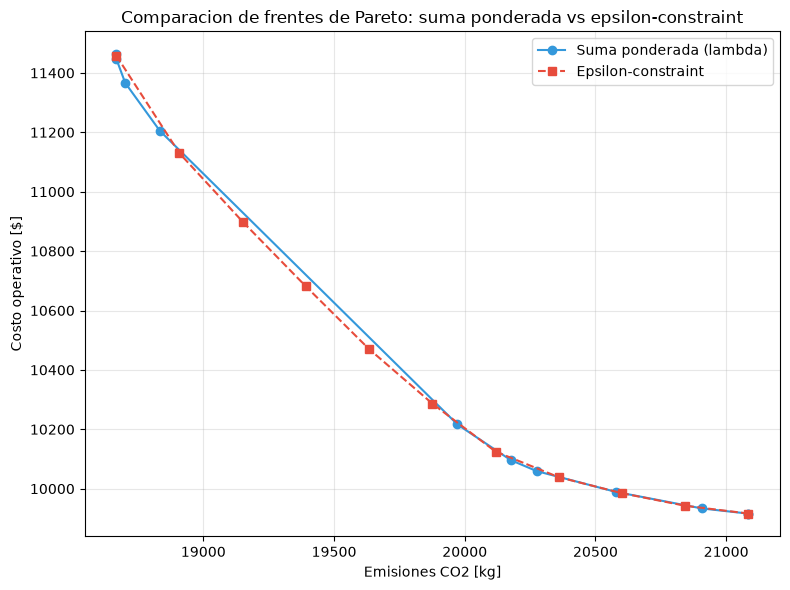

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

c_op_w = [r['c_op'] for r in pareto_results]
co2_w  = [r['c_em_kg'] for r in pareto_results]
ax.plot(co2_w, c_op_w, 'o-', color='#3498db', label='Suma ponderada (lambda)', ms=6)

c_op_e = [r['c_op'] for r in epsilon_results if r['feasible']]
co2_e  = [r['c_em_kg'] for r in epsilon_results if r['feasible']]
ax.plot(co2_e, c_op_e, 's--', color='#e74c3c', label='Epsilon-constraint', ms=6)

ax.set_xlabel('Emisiones CO2 [kg]')
ax.set_ylabel('Costo operativo [$]')
ax.set_title('Comparacion de frentes de Pareto: suma ponderada vs epsilon-constraint')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/pareto_comparacion_metodos.png', dpi=300, bbox_inches='tight')
plt.show()

## Frente de Pareto: Costo Operativo vs. Emisiones CO2

Visualizacion al estilo Nemati Fig. 5.9. Cada punto es una solucion optima MILP para un valor de lambda. El frente de Pareto representa el conjunto de soluciones no dominadas: no es posible mejorar un objetivo sin empeorar el otro.

Se muestran dos paneles:
- Izquierda: Costo operativo [\$] vs. Emisiones CO2 [kg] (unidades naturales)
- Derecha: Costo operativo [\$] vs. Costo de externalidad CO2 [\$] (ambos monetizados)

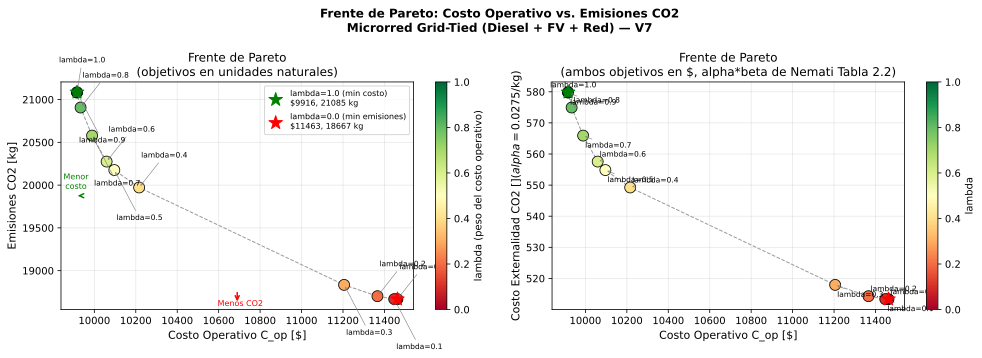

In [19]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

c_op_vals = [r['c_op'] for r in pareto_results]
c_em_vals = [r['c_em_kg'] for r in pareto_results]
c_em_cost_vals = [r['c_em_cost'] for r in pareto_results]
lam_vals = [r['lambda'] for r in pareto_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Frente de Pareto: Costo Operativo vs. Emisiones CO2\n'
             'Microrred Grid-Tied (Diesel + FV + Red) — V7', fontsize=12, fontweight='bold')

# Panel izquierdo: C_op [$] vs CO2 [kg]
ax1 = axes[0]
ax1.plot(c_op_vals, c_em_vals, 'k--', lw=1, alpha=0.4, zorder=1)
sc = ax1.scatter(c_op_vals, c_em_vals, c=lam_vals, cmap='RdYlGn',
               s=120, zorder=3, edgecolors='black', linewidths=0.8)

for i, (x, y, lv) in enumerate(zip(c_op_vals, c_em_vals, lam_vals)):
    offset_x = 2 if i < len(lam_vals)-1 else -18
    offset_y = 30 if i%2==0 else -50
    ax1.annotate(f'lambda={lv:.1f}', (x,y), textcoords='offset points',
                 xytext=(offset_x, offset_y), fontsize=7.5,
                 arrowprops=dict(arrowstyle='->', color='gray', lw=0.6))

ax1.scatter([c_op_vals[-1]], [c_em_vals[-1]], s=200, marker='*',
            color='green', zorder=5, label=f'lambda=1.0 (min costo)\n${c_op_vals[-1]:.0f}, {c_em_vals[-1]:.0f} kg')
ax1.scatter([c_op_vals[0]], [c_em_vals[0]], s=200, marker='*',
            color='red', zorder=5, label=f'lambda=0.0 (min emisiones)\n${c_op_vals[0]:.0f}, {c_em_vals[0]:.0f} kg')

plt.colorbar(sc, ax=ax1, label='lambda (peso del costo operativo)')
ax1.set_xlabel('Costo Operativo C_op [$]', fontsize=11)
ax1.set_ylabel('Emisiones CO2 [kg]', fontsize=11)
ax1.set_title('Frente de Pareto\n(objetivos en unidades naturales)')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(alpha=0.3)

ax1.annotate('', xy=(min(c_op_vals)-5, (max(c_em_vals)+min(c_em_vals))/2),
             xytext=(min(c_op_vals)+20, (max(c_em_vals)+min(c_em_vals))/2),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
ax1.text(min(c_op_vals)-5, (max(c_em_vals)+min(c_em_vals))/2+80,
         'Menor\ncosto', ha='center', fontsize=8, color='green')
ax1.annotate('', xy=((max(c_op_vals)+min(c_op_vals))/2, min(c_em_vals)-50),
             xytext=((max(c_op_vals)+min(c_op_vals))/2, min(c_em_vals)+100),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax1.text((max(c_op_vals)+min(c_op_vals))/2+15, min(c_em_vals)-80,
         'Menos CO2', ha='center', fontsize=8, color='red')

# Panel derecho: C_op [$] vs C_em_cost [$] (ambos monetizados)
ax2 = axes[1]
ax2.plot(c_op_vals, c_em_cost_vals, 'k--', lw=1, alpha=0.4, zorder=1)
sc2 = ax2.scatter(c_op_vals, c_em_cost_vals, c=lam_vals, cmap='RdYlGn',
                s=120, zorder=3, edgecolors='black', linewidths=0.8)

for i, (x, y, lv) in enumerate(zip(c_op_vals, c_em_cost_vals, lam_vals)):
    offset_x = 2 if i < len(lam_vals)-1 else -18
    offset_y = 5 if i%2==0 else -12
    ax2.annotate(f'lambda={lv:.1f}', (x,y), textcoords='offset points',
                 xytext=(offset_x, offset_y), fontsize=7.5,
                 arrowprops=dict(arrowstyle='->', color='gray', lw=0.6))

ax2.scatter([c_op_vals[-1]], [c_em_cost_vals[-1]], s=200, marker='*', color='green', zorder=5)
ax2.scatter([c_op_vals[0]], [c_em_cost_vals[0]], s=200, marker='*', color='red', zorder=5)

plt.colorbar(sc2, ax=ax2, label='lambda')
ax2.set_xlabel('Costo Operativo C_op [$]', fontsize=11)
ax2.set_ylabel('Costo Externalidad CO2 [$] (alpha = 0.0275 $/kg)', fontsize=11)
ax2.set_title('Frente de Pareto\n(ambos objetivos en $, alpha*beta de Nemati Tabla 2.2)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('images/pareto_frente_detalle.png', dpi=300, bbox_inches='tight')
plt.show()

## Comparacion de Despacho: lambda = 1.0 vs lambda = 0.0

Para entender que cambia en el despacho entre los dos extremos del frente de Pareto, se comparan visualmente las soluciones de minimo costo (lambda=1.0) y minimas emisiones (lambda=0.0).

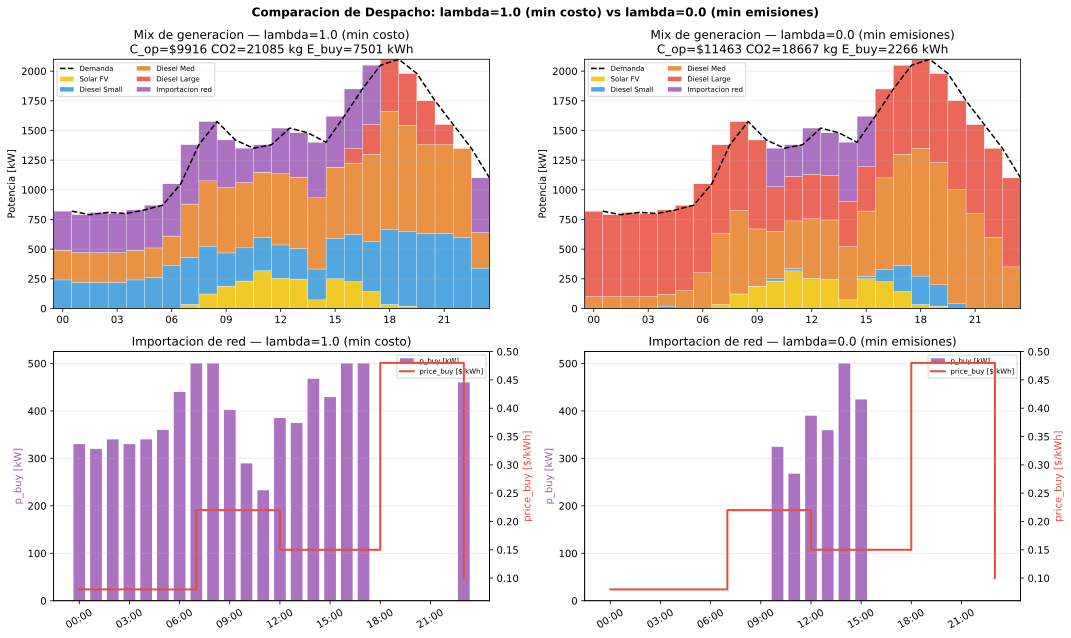

In [20]:
r_cost = pareto_results[-1]  # lambda=1.0: min costo
r_emis = pareto_results[0]   # lambda=0.0: min emisiones

hours = list(range(24))
gen_colors = {'diesel_small':'#3498db','diesel_med':'#e67e22','diesel_large':'#e74c3c'}
demand_vals = [expected_demand[i] for i in T]
pv_vals = [pv_output[i] for i in T]
buy_p = [price_buy[i] for i in T]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Comparacion de Despacho: lambda=1.0 (min costo) vs lambda=0.0 (min emisiones)',
             fontsize=12, fontweight='bold')

for col, (r, title) in enumerate([(r_cost, 'lambda=1.0 (min costo)'),
                                   (r_emis, 'lambda=0.0 (min emisiones)')]):
    ax_top = axes[0][col]
    ax_bot = axes[1][col]

    # Mix de generacion
    bottoms = np.zeros(24)
    ax_top.bar(hours, pv_vals, bottom=bottoms, color='#f1c40f', alpha=0.9,
               label='Solar FV', width=1.0, edgecolor='white', lw=0.3)
    bottoms += np.array(pv_vals)
    
    for g in GENERATORS:
        vals = r['output_vals'][g]
        ax_top.bar(hours, vals, bottom=bottoms, color=gen_colors[g], alpha=0.85,
                   label=g.replace('_',' ').title(), width=1.0, edgecolor='white', lw=0.3)
        bottoms += np.array(vals)
    
    ax_top.bar(hours, r['pbuy_vals'], bottom=bottoms, color='#9b59b6', alpha=0.85,
               label='Importacion red', width=1.0, edgecolor='white', lw=0.3)
    ax_top.plot([h+0.5 for h in hours], demand_vals, 'k--', lw=1.5, label='Demanda', zorder=5)
    
    ax_top.set_title(f'Mix de generacion — {title}\n'
                     f'C_op=${r["c_op"]:.0f} CO2={r["c_em_kg"]:.0f} kg E_buy={r["e_buy"]:.0f} kWh')
    ax_top.set_ylabel('Potencia [kW]')
    ax_top.set_xticks(range(0,24,3))
    ax_top.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
    ax_top.legend(fontsize=7, loc='upper left', ncol=2)
    ax_top.grid(alpha=0.3, axis='y')
    ax_top.set_xlim(-0.5, 23.5)

    # Importacion de red por hora
    ax_bot.bar(hours, r['pbuy_vals'], color='#9b59b6', alpha=0.85, width=0.7, label='p_buy [kW]')
    ax_bot2 = ax_bot.twinx()
    ax_bot2.step(hours, buy_p, where='post', color='#e74c3c', lw=2, label='price_buy [$/kWh]')
    ax_bot.set_ylabel('p_buy [kW]', color='#9b59b6')
    ax_bot2.set_ylabel('price_buy [$/kWh]', color='#e74c3c')
    ax_bot.set_title(f'Importacion de red — {title}')
    ax_bot.set_xticks(range(0,24,3))
    ax_bot.set_xticklabels([f'{h:02d}:00' for h in range(0,24,3)], rotation=30)
    lines1,lbl1=ax_bot.get_legend_handles_labels()
    lines2,lbl2=ax_bot2.get_legend_handles_labels()
    ax_bot.legend(lines1+lines2, lbl1+lbl2, fontsize=7)
    ax_bot.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('images/despacho_comparacion.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
print('Resumen comparativo extremos del frente de Pareto:')
hdr = '{:30} {:>14} {:>14} {:>10}'.format('', 'lambda=1.0', 'lambda=0.0', 'Delta')
print(hdr)
print('-'*70)
for key, label, fmt in [
    ('c_op', 'C_op [$]', '${:.2f}'),
    ('c_em_kg', 'CO2 total [kg]', '{:.0f} kg'),
    ('c_em_cost','C_em [$]', '${:.2f}'),
    ('e_buy', 'E_buy [kWh]', '{:.1f} kWh'),
    ('e_diesel', 'E_diesel [kWh]', '{:.1f} kWh'),
]:
    v1 = r_cost[key]; v0 = r_emis[key]
    print(' {:<28} {:>14} {:>14} {:>+10.1f}'.format(label, fmt.format(v1), fmt.format(v0), v0-v1))

Resumen comparativo extremos del frente de Pareto:
                                   lambda=1.0     lambda=0.0      Delta
----------------------------------------------------------------------
 C_op [$]                           $9916.37      $11462.66    +1546.3
 CO2 total [kg]                     21085 kg       18667 kg    -2418.2
 C_em [$]                            $579.84        $513.34      -66.5
 E_buy [kWh]                      7500.6 kWh     2265.7 kWh    -5234.9
 E_diesel [kWh]                  23188.8 kWh    28423.8 kWh    +5234.9


## Analisis del Trade-off en el Frente de Pareto

Visualizacion de como evolucionan las variables clave a lo largo del frente de Pareto.

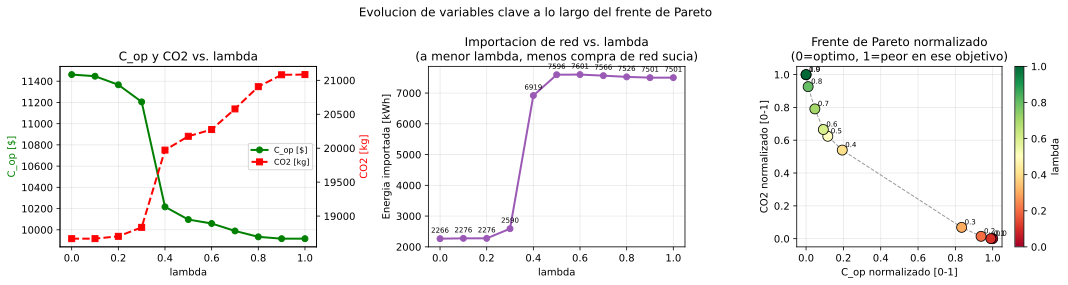

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Evolucion de variables clave a lo largo del frente de Pareto', fontsize=12)

lams = [r['lambda'] for r in pareto_results]
cops = [r['c_op'] for r in pareto_results]
ems = [r['c_em_kg'] for r in pareto_results]
ebuys = [r['e_buy'] for r in pareto_results]

# C_op y C_em vs lambda
ax1 = axes[0]
l1, = ax1.plot(lams, cops, 'go-', ms=6, lw=2, label='C_op [$]')
ax1b = ax1.twinx()
l2, = ax1b.plot(lams, ems, 'rs--', ms=6, lw=2, label='CO2 [kg]')
ax1.set_xlabel('lambda');
ax1.set_ylabel('C_op [$]', color='green')
ax1b.set_ylabel('CO2 [kg]', color='red')
ax1.set_title('C_op y CO2 vs. lambda')
ax1.legend([l1,l2],[l1.get_label(),l2.get_label()], fontsize=8, loc='center right')
ax1.grid(alpha=0.3)

# Importacion de red vs lambda
ax2 = axes[1]
ax2.plot(lams, ebuys, 'o-', color='#9b59b6', ms=6, lw=2)
ax2.set_xlabel('lambda'); ax2.set_ylabel('Energia importada [kWh]')
ax2.set_title('Importacion de red vs. lambda\n(a menor lambda, menos compra de red sucia)')
ax2.grid(alpha=0.3)
for x,y in zip(lams, ebuys):
    ax2.annotate(f'{y:.0f}', (x,y), textcoords='offset points', xytext=(0,6), fontsize=7, ha='center')

# Curva de intercambio Costo-CO2 normalizada
ax3 = axes[2]
c_op_min = min(cops); c_op_max = max(cops)
em_min = min(ems); em_max = max(ems)
cops_n = [(v-c_op_min)/(c_op_max-c_op_min) if c_op_max>c_op_min else 0 for v in cops]
ems_n = [(v-em_min)/(em_max-em_min) if em_max>em_min else 0 for v in ems]

ax3.plot(cops_n, ems_n, 'k--', lw=1, alpha=0.4)
sc3 = ax3.scatter(cops_n, ems_n, c=lams, cmap='RdYlGn', s=100, zorder=3,
                  edgecolors='black', linewidths=0.8)
for x,y,lv in zip(cops_n, ems_n, lams):
    ax3.annotate(f'{lv:.1f}', (x,y), textcoords='offset points',
                 xytext=(3,3), fontsize=7)
plt.colorbar(sc3, ax=ax3, label='lambda')
ax3.set_xlabel('C_op normalizado [0-1]')
ax3.set_ylabel('CO2 normalizado [0-1]')
ax3.set_title('Frente de Pareto normalizado\n(0=optimo, 1=peor en ese objetivo)')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('images/evolucion_variables_lambda.png', dpi=300, bbox_inches='tight')
plt.show()

## Análisis del Despacho: Impacto del Perfil Dinámico y Mix de Generadores

Al resolver una política multifuncional que combina la minimización de costos operativos y emisiones, las funciones objetivo se mezclan utilizando un factor de ponderación y un factor de nivelación. Variando este factor de ponderación entre 0 y 1, se logra obtener un conjunto óptimo de Pareto. En el siguiente gráfico de barras apiladas contrastamos las dos estrategias extremas del frente: **Minimizar Costos** ($\lambda = 1.0$) vs. **Minimizar Emisiones** ($\lambda = 0.0$).

Gracias a la implementación de un perfil dinámico para la red —que asume energía más limpia al mediodía por alta penetración solar y más sucia de noche por uso de térmicas— y al nuevo mix de generadores (con escasez de los diésel grandes y limpios), el comportamiento del solver cambia drásticamente:

* **Priorizando Costos ($\lambda = 1.0$):** El modelo importa la mayor cantidad posible de energía de la red porque es económicamente rentable, ignorando por completo que durante la noche y madrugada el factor de emisión de la red es muy elevado.
* **Priorizando Emisiones ($\lambda = 0.0$):** El modelo corta abruptamente la importación nocturna para evitar la red "sucia" y despacha a tope sus generadores propios más limpios (`diesel_large` y `diesel_med`). Sin embargo, vuelve a importar de la red al mediodía, aprovechando que en esa franja horaria la electricidad comprada es más "verde" que prender los generadores `diesel_small` (los más contaminantes de la microrred).

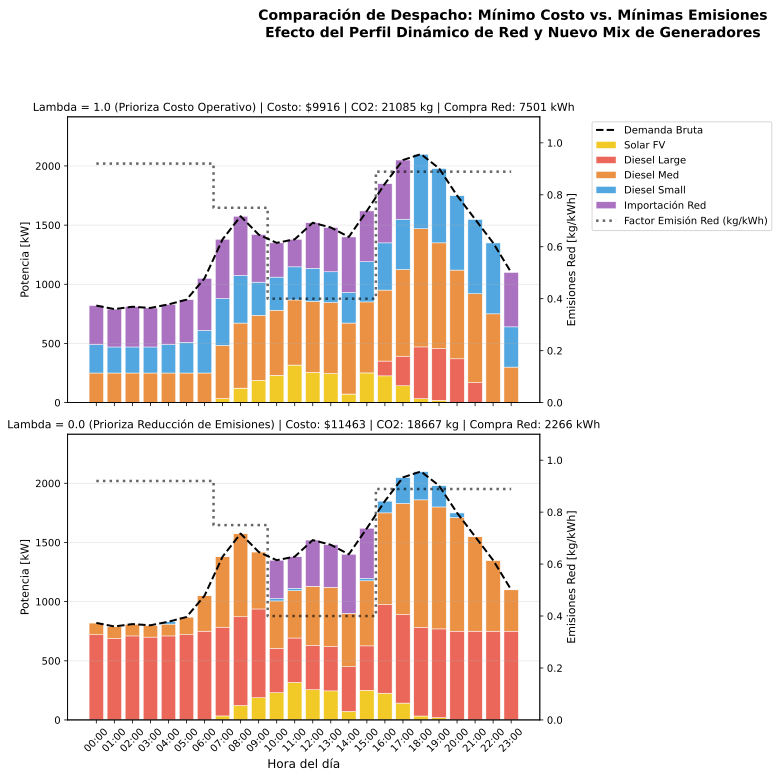

In [23]:
# Extraemos las soluciones extremas del barrido
r_cost = pareto_results[-1]  # lambda=1.0 (Prioriza Costo)
r_emis = pareto_results[0]   # lambda=0.0 (Prioriza Emisiones)

# Preparación de datos
hours = list(range(24))
gen_colors = {'diesel_small': '#3498db', 'diesel_med': '#e67e22', 'diesel_large': '#e74c3c'}
demand_vals = [expected_demand[i] for i in T]
pv_vals = [pv_output[i] for i in T]

# Perfil dinámico de emisiones de la red para graficar en eje secundario
beta_grid_vals = [BETA_GRID[h] for h in hours]

# Configuración de la figura
fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Comparación de Despacho: Mínimo Costo vs. Mínimas Emisiones\nEfecto del Perfil Dinámico de Red y Nuevo Mix de Generadores', 
             fontsize=14, fontweight='bold')

escenarios = [
    (r_cost, 'Lambda = 1.0 (Prioriza Costo Operativo)'),
    (r_emis, 'Lambda = 0.0 (Prioriza Reducción de Emisiones)')
]

for ax, (r, title) in zip(axes, escenarios):
    bottoms = np.zeros(24)

    # 1. Energía Solar FV (Base)
    ax.bar(hours, pv_vals, bottom=bottoms, color='#f1c40f', alpha=0.9, 
           label='Solar FV', width=0.8, edgecolor='white', lw=0.5)
    bottoms += np.array(pv_vals)

    # 2. Generadores Diesel (Ordenados de más limpios a más sucios)
    for g in ['diesel_large', 'diesel_med', 'diesel_small']:
        vals = r['output_vals'][g]
        ax.bar(hours, vals, bottom=bottoms, color=gen_colors[g], alpha=0.85, 
               label=g.replace('_',' ').title(), width=0.8, edgecolor='white', lw=0.5)
        bottoms += np.array(vals)

    # 3. Importación de la Red
    pbuy = r['pbuy_vals']
    ax.bar(hours, pbuy, bottom=bottoms, color='#9b59b6', alpha=0.85, 
           label='Importación Red', width=0.8, edgecolor='white', lw=0.5)

    # Línea de Demanda Bruta
    ax.plot(hours, demand_vals, 'k--', lw=2, label='Demanda Bruta', zorder=5)

    # Títulos y formato del eje principal
    ax.set_title(f'{title} | Costo: ${r["c_op"]:.0f} | CO2: {r["c_em_kg"]:.0f} kg | Compra Red: {r["e_buy"]:.0f} kWh', fontsize=11)
    ax.set_ylabel('Potencia [kW]', fontsize=11)
    ax.grid(alpha=0.3, axis='y')
    ax.set_ylim(0, max(demand_vals) * 1.15)

    # Eje secundario para mostrar el perfil de emisiones de la red
    ax2 = ax.twinx()
    ax2.step(hours, beta_grid_vals, where='mid', color='black', alpha=0.6, 
             lw=2.5, linestyle=':', label='Factor Emisión Red (kg/kWh)')
    ax2.set_ylabel('Emisiones Red [kg/kWh]', fontsize=11)
    ax2.set_ylim(0, 1.1)

    # Unificación de leyendas fuera del gráfico
    if ax == axes[0]:
        lines_1, labels_1 = ax.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', 
                  bbox_to_anchor=(1.10, 1), fontsize=10, frameon=True)

# Formato del eje X compartido
axes[1].set_xlabel('Hora del día', fontsize=12)
axes[1].set_xticks(hours)
axes[1].set_xticklabels([f'{h:02d}:00' for h in hours], rotation=45)

plt.tight_layout(rect=[0, 0, 0.80, 0.93]) # Deja espacio para la leyenda a la derecha
plt.savefig('images/despacho_perfil_red.png', dpi=300, bbox_inches='tight')
plt.show()

## Conclusiones

Este modelo implementa un **analisis biobjetivo Costo–Emisiones CO2** para una microrred *grid-tied* (diesel + FV + red), generando el frente de Pareto mediante el metodo de suma escalar ponderada con 11 puntos lambda in {0.0, 0.1, ..., 1.0}.

**Extensiones respecto a V6:**

1. **Funcion objetivo de emisiones:** $C^{\mathrm{em}} = \alpha_{\mathrm{CO_2}} [\beta_{\mathrm{DG}} \sum x_{g,t} + \beta_{\mathrm{grid}} \sum p^{\mathrm{buy}}_t]$, usando los factores de Nemati et al. Tabla 2.2. Ambos objetivos estan en $, lo que permite la suma directa sin factor de escala adicional.

2. **Funcion `build_and_solve(lambda)`:** encapsula la construccion y resolucion completa del modelo MILP para un lambda dado. Se llama 11 veces en el barrido del frente de Pareto. Cada llamada produce una instancia independiente y retorna los valores de ambos objetivos por separado, sin ponderacion.

3. **Frente de Pareto:** los 11 puntos forman el conjunto de soluciones no dominadas. Se visualiza tanto en unidades naturales ($ vs kg CO2) como normalizado, al estilo de Nemati Fig. 5.9.

**Trade-off observado:**

El resultado mas interesante es que $\beta_{\mathrm{grid}} = 889\,\mathrm{g/kWh} > \beta_{\mathrm{DG}} = 649\,\mathrm{g/kWh}$: la red alemana de 2017 es mas sucia que los generadores diesel propios. Por eso:

- Con **lambda=1.0** (solo costo): el solver importa energia barata de la red en horas valle -> menor costo operativo, pero **mayor** emision total.
- Con **lambda=0.0** (solo emisiones): el solver reduce la importacion de red -> menor emision, pero **mayor** costo operativo.

El mecanismo de reduccion de emisiones no es encender mas diesel (lo cual aumentaria las emisiones diesel), sino **reducir la importacion de la fuente mas contaminante** (la red) y redistribuir la carga entre los generadores propios. La generacion FV permanece inalterada en todos los puntos (es no gestionable y siempre preferida por costo cero y emision cero).

Este resultado ilustra la importancia de conocer el mix electrico de la red de servicio antes de tomar decisiones de operacion basadas en criterios ambientales. Un mix con alta participacion de renovables (como Argentina en momentos de alto caudal hidraulico) produciria el trade-off inverso.

In [24]:
from dotenv import load_dotenv
import os

# Cargar variables de entorno desde el archivo .env
load_dotenv()

# Obtener la clave API desde las variables de entorno
api_key = os.getenv("MISTRAL_API_KEY")

# Importación compatible con múltiples versiones del SDK
try:
    from mistralai import Mistral
except ImportError:
    from mistralai.client import Mistral

client = Mistral(api_key=api_key)


# Tomamos los resultados del frente de Pareto
c_op_vals = [r['c_op'] for r in pareto_results]
c_em_vals = [r['c_em_kg'] for r in pareto_results]
lams = [r['lambda'] for r in pareto_results]

# Construimos un resumen para Mistral
resumen = f"""
Resultados del frente de Pareto para una microrred grid-tied:

- Rango de Costo Operativo (C_op): ${min(c_op_vals):.0f} - ${max(c_op_vals):.0f}
- Rango de Emisiones CO2: {min(c_em_vals):.0f} - {max(c_em_vals):.0f} kg

Puntos del frente de Pareto:
"""
for lam, cop, em in zip(lams, c_op_vals, c_em_vals):
    resumen += f"  lambda={lam:.1f}: C_op=${cop:.0f}, CO2={em:.0f} kg\n"

# Pedimos a Mistral que analice el trade-off
response = client.chat.complete(
    model="mistral-small-latest",
    messages=[
        {"role": "system", "content": "Eres un experto en sistemas de energía y optimización. Analiza estos resultados de un frente de Pareto para una microrred."},
        {"role": "user", "content": f"Analiza este frente de Pareto y dame insights sobre el trade-off entre costo y emisiones:\n{resumen}"}
    ]
)

print(response.choices[0].message.content)

ModuleNotFoundError: No module named 'dotenv'